# MNIST

## 调包

In [1]:
import torch    # PyTorch 核心，提供张量和自动微分
import torch.nn as nn      # 神经网络模块（层、损失函数等）
import torch.nn.functional as F
import torch.optim as optim      # 优化器（SGD、Adam 等）
from torch.ao.nn.quantized.functional import conv2d
from torch.utils.data import DataLoader     # 数据加载器，自动分批次
from torchvision import datasets,transforms     # 视觉数据集和图像变换
from torchvision.datasets.utils import download_url

**类比理解：**

- `torch` = 整个厨房
- `torch.nn` = 各种锅碗瓢盆（网络层）
- `torch.optim` = 火候调节器（优化算法）
- `DataLoader` = 传菜员（把数据一批批送给模型）
- `torchvision` = 食材仓库（内置了 MNIST、CIFAR 等数据集）

## 超参数

In [2]:
batch_size=64       # 每次喂给模型多少张图片
learning_rate=0.01      # 每次更新参数的步长大小
num_epochs=10       # 整个训练集过几遍

'''
可以使用config.py来调用超参数
目的是使实验可以复现，易于对比
from config import config,set_seed

set_seed(config['seed'])

'''

"\n可以使用config.py来调用超参数\n目的是使实验可以复现，易于对比\nfrom config import config,set_seed\n\nset_seed(config['seed'])\n\n"

**什么是超参数？**

超参数是你在训练前手动设置的参数，模型自己学不了，需要你来调。

- **batch_size（批大小）**：
	- 不是一张一张喂，而是一批一批喂，效率更高
	- 太小：训练慢，梯度噪声大；太大：占内存多，可能收敛差
	- 常用值：32、64、128

- **learning_rate（学习率）**：
	- 控制每次参数更新的幅度
	- 太大：参数乱跳，不收敛；太小：收敛极慢
	- 常用值：0.001、0.01、0.1

- **num_epochs（训练轮数）**：
	- 整个训练集从头到尾过一遍 = 1 个 epoch
	- 太少：欠拟合；太多：过拟合

## 数据变换

In [3]:

# 训练时的 transform（加入数据增强，让模型见到更多变体）
transform = transforms.Compose([
    transforms.RandomRotation(15),                                          # 随机旋转 ±15°，对抗你写字时的倾斜
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), shear=10),    # 随机平移 + 错切（模拟不同书写角度）
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 测试集 / 推理时不做增强（只做必要的格式转换）
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])


**为什么要 ToTensor()？**

PyTorch 的模型只认识 Tensor（张量），不认识图片文件。

- 原始图片：PIL Image，像素值 0~255
- 转换后：Tensor，形状 `[1, 28, 28]`，值域 `[0.0, 1.0]`

**为什么要 Normalize()？**

把数据标准化到均值为0、方差为1附近，让训练更稳定、收敛更快。

- `0.1307` 是 MNIST 训练集的像素均值（官方计算好的）
- `0.3081` 是 MNIST 训练集的像素标准差

公式：`normalized = (pixel - 0.1307) / 0.3081`

**Compose 是什么？**

把多个变换串联起来，按顺序依次执行，就像流水线。

## 加载数据集

In [4]:
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform        # 训练集：带增强
)

test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform_test     # 测试集：不做增强
)


## DataLoader

In [5]:
train_loader=DataLoader(
    train_dataset,
    batch_size=batch_size,
    #batch_size=config['batch_size'],
    shuffle=True
)

test_loader=DataLoader(
    test_dataset,
    batch_size=batch_size,
    #batch_size=config['batch_size'],
    shuffle=True
)

**DataLoader 做了什么？**

把 60,000 张图片自动切成一批批（每批 64 张），每次训练取一批。

- 60,000 / 64 ≈ 938 批，所以每个 epoch 要循环 938 次
- `shuffle=True`：每个 epoch 开始前重新打乱，防止过拟合

**数据形状：**

- 每批数据：`images.shape = [64, 1, 28, 28]`
	- 64 = batch_size
	- 1 = 颜色通道数（灰度图只有1个通道）
	- 28, 28 = 图片高度和宽度
- 每批标签：`labels.shape = [64]`，值为 0~9

## 模型定义：神经网络长什么样

In [6]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        self.net=nn.Sequential(
            # 卷积层
            nn.Conv2d(1,32,kernel_size=3,padding=1),
            nn.BatchNorm2d(32),        #批归一化
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2,2),

            nn.Flatten(),
            nn.Linear(64*7*7,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,10),
        )

    def forward(self,x):
        # x 的初始形状: [batch, 1, 28, 28]
        return self.net(x)

### 5.1 nn.Module 是什么？

所有 PyTorch 模型都要继承 `nn.Module`，它提供了：

- 自动追踪所有参数（权重、偏置）
- `parameters()` 方法让优化器能找到所有参数
- `train()` / `eval()` 模式切换

`super().__init__()` 必须调用，初始化父类。

### 5.2 卷积层 nn.Conv2d

```python
nn.Conv2d(in_channels, out_channels, kernel_size,stride, padding)
```

| 参数         | 含义                       | 示例中的值     |
| ------------ | -------------------------- |-----------|
| in_channels  | 输入的通道数               | 1（灰度图）    |
| out_channels | 输出的通道数（卷积核个数） | 32        |
| kernel_size  | 卷积核大小                 | 3（即3×3）   |
| stride       | 卷积核在图片上滑动时，每次只挪动 1 个像素| 1         |
| padding      | 边缘填充像素数             | 1（保持尺寸不变） |

**卷积在做什么？**

用一个小窗口（3×3）在图片上滑动，提取局部特征（边缘、纹理等）。

- 32个卷积核 = 提取32种不同特征
- 输出形状：`[batch, 32, 28, 28]`（padding=1 保持了28×28）

**参数量计算：**

- conv1：`3×3×1×32 + 32(偏置) = 320` 个参数
- conv2：`3×3×32×64 + 64(偏置) = 18,496` 个参数

### 5.3 池化层 nn.MaxPool2d

```python
nn.MaxPool2d(kernel_size=2, stride=2)
```

在 2×2 的窗口里取最大值，图片尺寸缩小一半。

```
28×28 → MaxPool → 14×14
14×14 → MaxPool → 7×7
```

**为什么要池化？**

- 降低特征图尺寸，减少计算量
- 保留最显著的特征，增加平移不变性

### 5.4 激活函数 nn.ReLU

```python
ReLU(x) = max(0, x)
```

- 负数变成0，正数保持不变
- **为什么需要激活函数？** 没有激活函数，多层网络等价于一层线性变换，无法学习复杂特征
- ReLU 计算简单，不会有梯度消失问题（相比 Sigmoid）

### 5.5 展平操作 view

```python
x = x.view(-1, 64 * 7 * 7)
```

把三维特征图 `[batch, 64, 7, 7]` 展平成一维向量 `[batch, 3136]`，才能送入全连接层。

- `-1` 表示这个维度自动计算（就是 batch_size）
- `64 * 7 * 7 = 3136`

### 5.6 全连接层 nn.Linear

```python
nn.Linear(in_features, out_features)
```

就是矩阵乘法：`output = input × W + b`

- `fc1`：3136 → 128，提取高级特征
- `fc2`：128 → 10，输出10个类别的分数（logits）

**最后输出的10个数是什么？**

每个数对应一个数字类别（0~9）的"得分"，数值越大表示模型越认为是这个类别。还不是概率，需要经过 Softmax 才变成概率（但损失函数会自动处理）。

### 5.7 Dropout

```python
nn.Dropout(p=0.5)
```

训练时随机把 50% 的神经元输出置为0，防止过拟合。

- 测试时自动关闭（调用 `model.eval()` 后）
- 相当于每次训练用不同的"子网络"，增强泛化能力

### 5.8 forward 方法

`forward` 定义了数据从输入到输出的流动路径。

- 你不直接调用 `forward`，而是直接调用模型：`output = model(x)`
- PyTorch 会自动调用 `forward`

 ## 6. 损失函数与优化器

In [7]:
model=CNN()

# 使用GPU
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model=model.to(device)

criterion=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=learning_rate,momentum=0.9)
#optimizer=optim.SGD(model.parameters(),lr=config['lr'],momentum=0.9)
# 或用 Adam
# optimizer=optim.Adam(model.parameters(),lr=learning_rate)

### 6.1 损失函数 CrossEntropyLoss

**交叉熵损失**，分类任务的标准选择。

它内部做了两件事：

1. Softmax：把10个原始分数转成概率分布（加起来=1）
2. 负对数似然：`loss = -log(正确类别的概率)`

**直觉理解：**

- 如果模型对正确答案很有把握（概率接近1），loss 接近 0
- 如果模型完全猜错（概率接近0），loss 趋向无穷大

```
预测概率 → 0.9  →  loss = -log(0.9) ≈ 0.10  （好）
预测概率 → 0.1  →  loss = -log(0.1) ≈ 2.30  （差）
```

### 6.2 优化器 SGD / Adam

优化器负责根据梯度更新模型参数。

**SGD（随机梯度下降）：**

```
新参数 = 旧参数 - 学习率 × 梯度
```

model.parameters()
把刚才你网络里所有层（conv 的卷积核、fc 的权重……）的可学习参数，统统交给优化器。这样优化器就知道要拧哪些螺丝。

相当于你把整个工具箱递给师傅：“所有可以调整的零件都在这儿了，帮我拧到最佳状态”。

**momentum=0.9 是什么？**

动量，让更新方向有"惯性"，避免在梯度方向频繁震荡，加速收敛。

无动量：每次根据当前梯度直接拧一下，容易卡在小沟里晃悠。

有动量：积累了之前的调整方向，下坡时越滚越快，还能滚过小平地（局部最优点）。

0.9 表示这次更新 = 10% 现在的梯度 + 90% 上一次的更新方向，保留大部分“历史惯性”。

**Adam（推荐初学者用）：**

- 自适应学习率，不同参数用不同步长
- 通常比 SGD 更容易调，默认 `lr=0.001` 就能跑得不错

 ## 7. 训练循环：模型怎么学习的

In [8]:
def train(epoch):
    model.train()
    for batch_idx,(image,labels) in enumerate(train_loader):

        image,labels=image.to(device),labels.to(device)

        # 清除梯度
        optimizer.zero_grad()

        # 前行传导（输入图片，得到预测结果）
        output=model(image)     # outputs.shape = [64, 10]

        # 计算损失
        loss=criterion(output,labels)  # 0维张量

        # 反向传播，计算每个参数梯度
        loss.backward()

        # 更新参数
        optimizer.step()

        # 打印进度
        if batch_idx%100==0:
            print(f'Epoch{epoch},Batch{batch_idx},Loss:{loss.item():.4f}')

### 训练的5步核心循环

每一批数据都要走这5步，缺一不可：

```
① zero_grad()   清零梯度  ← 必须在每批开始时清零，否则梯度累加
② forward       前向传播  ← 数据流过网络，得到预测
③ loss          计算损失  ← 预测和真实标签的差距
④ backward()    反向传播  ← 自动计算所有参数的梯度
⑤ step()        更新参数  ← 用梯度更新权重
```

**为什么要 zero_grad()？**

PyTorch 默认会把梯度累加（不是覆盖），这是为了支持某些特殊训练技巧。
但普通训练中，每批数据的梯度应该独立计算，所以每批开始前必须清零。

**loss.item() 是什么？**

`.item()` 把只有一个元素的 Tensor 转成 Python 的普通浮点数，方便打印。

---

##

## 8. 测试循环：怎么评估模型好坏

In [9]:
def text():
    model.eval()

    text_loss=0
    correct=0
    total=0

    with torch.no_grad():       # 关闭梯度计算，节省内存和计算
        for image,labels in test_loader:

            image,labels=image.to(device),labels.to(device)

            outputs=model(image)
            loss=criterion(outputs,labels)
            text_loss+=loss.item()

            # 取概率最大的类别作为预测结果
            _,prediction=torch.max(outputs,dim=1)
            total+=labels.size(0)
            correct+=(prediction==labels).sum().item()

    accuracy=100*correct/total
    avg_loss=text_loss/len(test_loader)
    print(f'Text Loss:{avg_loss:.4f},Accuracy{accuracy:.2f}%')
    return accuracy




### 关键点解析

**model.eval() vs model.train()**

| 模式    | Dropout        | BatchNorm            |
| ------- | -------------- | -------------------- |
| train() | 随机丢弃神经元 | 用当前批次统计量     |
| eval()  | 全部保留       | 用训练时积累的统计量 |

测试时必须用 `eval()`，否则结果不稳定。

**torch.no_grad()**

测试时不需要计算梯度（不更新参数），用 `no_grad()` 关掉梯度追踪：

- 节省约一半内存
- 加快计算速度

**torch.max(outputs, dim=1)**

返回两个值：

- 第一个（`_`）：每行的最大值（我们不需要）
- 第二个（`predicted`）：最大值所在的列索引，即预测的类别

```python
# 例子：outputs = [[0.1, 0.8, 0.05, ...], ...]
# torch.max 沿 dim=1（列方向）找最大值
# predicted = [1, ...]  ← 预测为数字1
```

**准确率计算：**

```python
(predicted == labels)  # 布尔 Tensor，预测对的位置为 True
.sum()                 # 统计 True 的个数（预测正确的数量）
.item()                # 转成 Python int
```

---

## 9.主循环

In [10]:
for epoch in range(1,num_epochs+1):
#for epoch in range(1,config['num_epochs']+1):
    train(epoch)
    text()

Epoch1,Batch0,Loss:2.4085
Epoch1,Batch100,Loss:0.3884
Epoch1,Batch200,Loss:0.3117
Epoch1,Batch300,Loss:0.1734
Epoch1,Batch400,Loss:0.3768
Epoch1,Batch500,Loss:0.1920
Epoch1,Batch600,Loss:0.2774
Epoch1,Batch700,Loss:0.2135
Epoch1,Batch800,Loss:0.2486
Epoch1,Batch900,Loss:0.2297
Text Loss:0.0442,Accuracy98.53%
Epoch2,Batch0,Loss:0.4775
Epoch2,Batch100,Loss:0.0821
Epoch2,Batch200,Loss:0.3333
Epoch2,Batch300,Loss:0.0618
Epoch2,Batch400,Loss:0.2482
Epoch2,Batch500,Loss:0.1446
Epoch2,Batch600,Loss:0.1222
Epoch2,Batch700,Loss:0.1552
Epoch2,Batch800,Loss:0.0773
Epoch2,Batch900,Loss:0.0821
Text Loss:0.0336,Accuracy98.83%
Epoch3,Batch0,Loss:0.1208
Epoch3,Batch100,Loss:0.0842
Epoch3,Batch200,Loss:0.1514
Epoch3,Batch300,Loss:0.0958
Epoch3,Batch400,Loss:0.0717
Epoch3,Batch500,Loss:0.1428
Epoch3,Batch600,Loss:0.0896
Epoch3,Batch700,Loss:0.1555
Epoch3,Batch800,Loss:0.1063
Epoch3,Batch900,Loss:0.1623
Text Loss:0.0269,Accuracy99.11%
Epoch4,Batch0,Loss:0.2140
Epoch4,Batch100,Loss:0.1962
Epoch4,Batch200,

## 10.保存模型

In [11]:
torch.save(model.state_dict(),'mnist_cnn.pth')

## 11.使用自己的图片

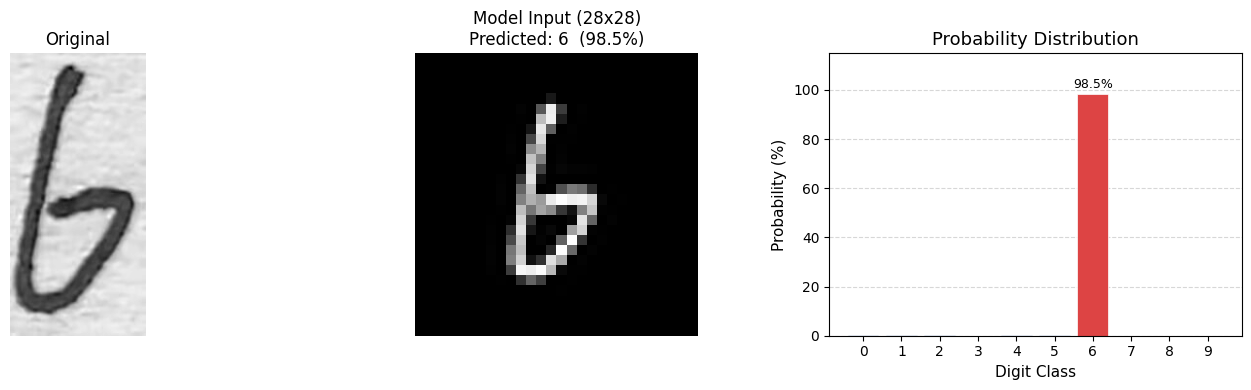

Predicted: 6,  Confidence: 98.51%
{0: '0.32%', 1: '0.14%', 2: '0.42%', 3: '0.00%', 4: '0.22%', 5: '0.31%', 6: '98.51%', 7: '0.00%', 8: '0.07%', 9: '0.02%'}


In [16]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torch.nn.functional as F


def _otsu_threshold(arr):
    """纯 numpy 实现的 Otsu 自动阈值，找使前景/背景类间方差最大的分割点。"""
    hist, _ = np.histogram(arr.flatten(), bins=256, range=(0, 256))
    hist = hist.astype(float)
    total = hist.sum()
    sum_total = np.dot(np.arange(256), hist)

    best_thresh, best_var = 0, 0
    sum_bg, weight_bg = 0.0, 0.0

    for t in range(256):
        weight_bg += hist[t]
        if weight_bg == 0 or weight_bg == total:
            continue
        weight_fg = total - weight_bg
        sum_bg += t * hist[t]
        mean_bg = sum_bg / weight_bg
        mean_fg = (sum_total - sum_bg) / weight_fg
        var = weight_bg * weight_fg * (mean_bg - mean_fg) ** 2
        if var > best_var:
            best_var, best_thresh = var, t

    return best_thresh


def preprocess_image(image_path):
    img = Image.open(image_path).convert('L')
    arr = np.array(img, dtype=np.float32)

    # 智能翻转：MNIST 是黑底白字
    if arr.mean() > 127:
        arr = 255.0 - arr

    # Otsu 自适应阈值：自动找前景（笔画）与背景的最佳分割点
    # 比固定值 50 或简单百分比都更稳健，不受照片亮度/对比度影响
    thresh = _otsu_threshold(arr)
    arr = np.where(arr > thresh, arr, 0.0)

    rows = np.any(arr > 0, axis=1)
    cols = np.any(arr > 0, axis=0)

    if not rows.any():
        return Image.fromarray(np.zeros((28, 28), dtype=np.uint8))

    r_min, r_max = np.where(rows)[0][[0, -1]]
    c_min, c_max = np.where(cols)[0][[0, -1]]

    h = r_max - r_min + 1
    w = c_max - c_min + 1
    pad = int(max(h, w) * 0.2)

    r_min = max(0, r_min - pad)
    r_max = min(arr.shape[0] - 1, r_max + pad)
    c_min = max(0, c_min - pad)
    c_max = min(arr.shape[1] - 1, c_max + pad)
    cropped = arr[r_min:r_max + 1, c_min:c_max + 1]

    h, w = cropped.shape
    if h > w:
        left = (h - w) // 2
        right = (h - w) - left
        cropped = np.pad(cropped, ((0, 0), (left, right)))
    elif w > h:
        top = (w - h) // 2
        bottom = (w - h) - top
        cropped = np.pad(cropped, ((top, bottom), (0, 0)))

    pil_cropped = Image.fromarray(cropped.astype(np.uint8))
    pil_20 = pil_cropped.resize((20, 20), Image.LANCZOS)

    canvas = np.zeros((28, 28), dtype=np.uint8)
    canvas[4:24, 4:24] = np.array(pil_20)

    return Image.fromarray(canvas)


def predict_image(image_path, model, device):
    img_processed = preprocess_image(image_path)

    transform_infer = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    tensor = transform_infer(img_processed).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(tensor)
        probs_np = F.softmax(logits, dim=1).squeeze().cpu().numpy()
    predicted = int(probs_np.argmax())

    original = Image.open(image_path).convert('L')
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original', fontsize=12)
    axes[0].axis('off')

    axes[1].imshow(img_processed, cmap='gray')
    axes[1].set_title(
        f'Model Input (28x28)\nPredicted: {predicted}  ({probs_np[predicted]*100:.1f}%)',
        fontsize=12
    )
    axes[1].axis('off')

    colors = ['#4C72B0'] * 10
    colors[predicted] = '#DD4444'
    bars = axes[2].bar(range(10), probs_np * 100, color=colors,
                       edgecolor='white', linewidth=0.5)
    axes[2].set_xticks(range(10))
    axes[2].set_xlabel('Digit Class', fontsize=11)
    axes[2].set_ylabel('Probability (%)', fontsize=11)
    axes[2].set_title('Probability Distribution', fontsize=13)
    axes[2].set_ylim(0, 115)
    axes[2].yaxis.grid(True, linestyle='--', alpha=0.5)
    axes[2].set_axisbelow(True)

    for bar, p in zip(bars, probs_np):
        if p > 0.005:
            axes[2].text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1,
                f'{p*100:.1f}%',
                ha='center', va='bottom', fontsize=9
            )

    plt.tight_layout()
    plt.savefig('prediction_result.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Predicted: {predicted},  Confidence: {probs_np[predicted]*100:.2f}%')
    print({i: f'{p*100:.2f}%' for i, p in enumerate(probs_np)})
    return predicted, probs_np


image_path = r'028442e669b0c402d5c0cee7a97289af.jpg'

# 如果重启了 kernel，先取消注释下面这行重新加载权重：
# model.load_state_dict(torch.load('mnist_cnn.pth', map_location=device))

predicted_digit, probabilities = predict_image(image_path, model, device)
